<a href="https://colab.research.google.com/github/jansle2005/Data-Science-Repository/blob/master/e_t_i_c_e.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importaçõeos e leitura do dataframe

In [97]:
pip install xlsxwriter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.9/159.9 kB 3.1 MB/s eta 0:00:00


In [57]:
import pandas as pd
import matplotlib.pyplot as plt

In [58]:
# Ler o arquivo Livro_Razao_2022___limpo.xlsx
df = pd.read_excel("Livro_Razao_2022___limpo.xlsx")

# Tranformando a coluna 'CREDITO' em float number
df['CRÉDITO'] = df['CRÉDITO'].astype(str).str.replace('.', '').str.replace(',', '.').astype(float)
df['CRÉDITO'] = df['CRÉDITO'].round(2)

In [59]:
df

,DATA,Mês,HISTÓRICO,CONTRAPARTIDA,CR-Cp,CHAVE,CRÉDITO,Unnamed: 7,CHECK VALUE,SALDO
0,2022-01-03 00:00:00,jan,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0032 0001,1,1.637037e+09,2614.04,"2.722,31C","2.722,31","2.722,31"
1,2022-01-04 00:00:00,jan,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0350 0001,1,1.637037e+09,41236.62,"43.958,93C","43.958,93",43958.93
2,2022-01-04 00:00:00,jan,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0032 0001,1,1.637037e+09,2946.96,"46.905,89C","46.905,89",46905.89
3,2022-01-04 00:00:00,jan,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0032 0001,1,1.637037e+09,3997.97,"50.903,86C","50.903,86",50903.86
4,2022-01-05 00:00:00,jan,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0097 0001,1,1.637037e+09,2734.19,"53.638,05C","53.638,05",53638.05
...,...,...,...,...,...,...,...,...,...,...
2596,2022-12-22 00:00:00,dez,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0087 0001,1,1.638011e+09,100.00,"122.027.647,01C","122.027.647,01",122027647.01
2597,2022-12-22 00:00:00,dez,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0090 0001,1,1.638011e+09,3900.00,"122.031.547,01C","122.031.547,01",122031547.01
2598,2022-12-29 00:00:00,dez,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0115 0001,1,1.638011e+09,1608.82,"122.033.155,83C","122.033.155,83",122033155.83
2599,2022-12-29 00:00:00,dez,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0040 0001,1,1.638011e+09,4000.00,"122.037.155,83C","122.037.155,83",122037155.83


In [94]:
# Agrupar o DataFrame por mês e iterar sobre os grupos
# Dicionário para garantir a ordem dos meses
ordem_meses = ['jan', 'fev', 'mar', 'abr', 'mai', 'jun',
               'jul', 'ago', 'set', 'out', 'nov', 'dez']

# Largura para alinhamento
largura_soma = 20
largura_registros = 10

# Agrupar, ordenar e iterar
for mes in ordem_meses:
    grupo = df[df['Mês'] == mes]
    if not grupo.empty:
        globals()[f'df_{mes}'] = grupo
        soma_creditos = grupo['CRÉDITO'].sum()
        quantidade_registros = len(grupo)
        soma_formatada = f"R$ {soma_creditos:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.')
        print(f'Mês: {mes.capitalize()}  Quantidade de Registros: {str(quantidade_registros).rjust(largura_registros)} - Soma dos CRÉDITOS: {soma_formatada.rjust(largura_soma)}')

Mês: Jan  Quantidade de Registros:         57 - Soma dos CRÉDITOS:      R$ 1.026.903,26
Mês: Fev  Quantidade de Registros:        172 - Soma dos CRÉDITOS:      R$ 6.048.682,67
Mês: Mar  Quantidade de Registros:        206 - Soma dos CRÉDITOS:     R$ 11.554.415,90
Mês: Abr  Quantidade de Registros:        152 - Soma dos CRÉDITOS:      R$ 7.031.817,69
Mês: Mai  Quantidade de Registros:        278 - Soma dos CRÉDITOS:    R$ 126.508.249,03
Mês: Jun  Quantidade de Registros:        204 - Soma dos CRÉDITOS:      R$ 8.385.736,10
Mês: Jul  Quantidade de Registros:        208 - Soma dos CRÉDITOS:    R$ 628.284.614,00
Mês: Ago  Quantidade de Registros:        217 - Soma dos CRÉDITOS:    R$ 158.790.803,54
Mês: Set  Quantidade de Registros:        237 - Soma dos CRÉDITOS:     R$ 11.156.618,38
Mês: Out  Quantidade de Registros:        196 - Soma dos CRÉDITOS:      R$ 8.346.670,84
Mês: Nov  Quantidade de Registros:        247 - Soma dos CRÉDITOS:     R$ 12.370.685,84
Mês: Dez  Quantidade de Registro

In [98]:
import xlsxwriter
# Criar um arquivo Excel com múltiplas abas
with pd.ExcelWriter('meses.xlsx', engine='xlsxwriter') as writer:
    for mes in ordem_meses:
        grupo = df[df['Mês'] == mes]
        if not grupo.empty:
            grupo.to_excel(writer, sheet_name=mes.capitalize(), index=False)

In [82]:
df_jan

,DATA,Mês,HISTÓRICO,CONTRAPARTIDA,CR-Cp,CHAVE,CRÉDITO,Unnamed: 7,CHECK VALUE,SALDO
0,2022-01-03,jan,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0032 0001,1,1.637037e+09,2614.04,"2.722,31C","2.722,31","2.722,31"
1,2022-01-04,jan,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0350 0001,1,1.637037e+09,41236.62,"43.958,93C","43.958,93",43958.93
2,2022-01-04,jan,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0032 0001,1,1.637037e+09,2946.96,"46.905,89C","46.905,89",46905.89
3,2022-01-04,jan,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0032 0001,1,1.637037e+09,3997.97,"50.903,86C","50.903,86",50903.86
4,2022-01-05,jan,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0097 0001,1,1.637037e+09,2734.19,"53.638,05C","53.638,05",53638.05
5,2022-01-06,jan,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0024 0001,1,1.637037e+09,4852.00,"58.490,05C","58.490,05",58490.05
6,2022-01-07,jan,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0179 0001,1,1.637037e+09,32992.96,"91.483,01C","91.483,01",91483.01
7,2022-01-10,jan,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0140 0001,1,1.637037e+09,25.44,"91.508,45C","91.508,45",91508.45
8,2022-01-11,jan,Vr Ref.Servic;:o Presiado Nola Fiscal de Servi...,1.1.02.01.0051 0001,1,1.637037e+09,37066.84,"128.575,29C","128.575,29",128575.29
9,2022-01-11,jan,Vr Ref.Servic;:o Presiado Nola Fiscal de Servi...,1.1.02.01.0051 0001,1,1.637037e+09,15139.97,"143.715,26C","143.715,26",143715.26


In [80]:
df_jan

,DATA,Mês,HISTÓRICO,CONTRAPARTIDA,CR-Cp,CHAVE,CRÉDITO,Unnamed: 7,CHECK VALUE,SALDO
0,2022-01-03,jan,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0032 0001,1,1.637037e+09,2614.04,"2.722,31C","2.722,31","2.722,31"
1,2022-01-04,jan,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0350 0001,1,1.637037e+09,41236.62,"43.958,93C","43.958,93",43958.93
2,2022-01-04,jan,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0032 0001,1,1.637037e+09,2946.96,"46.905,89C","46.905,89",46905.89
3,2022-01-04,jan,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0032 0001,1,1.637037e+09,3997.97,"50.903,86C","50.903,86",50903.86
4,2022-01-05,jan,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0097 0001,1,1.637037e+09,2734.19,"53.638,05C","53.638,05",53638.05
5,2022-01-06,jan,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0024 0001,1,1.637037e+09,4852.00,"58.490,05C","58.490,05",58490.05
6,2022-01-07,jan,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0179 0001,1,1.637037e+09,32992.96,"91.483,01C","91.483,01",91483.01
7,2022-01-10,jan,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0140 0001,1,1.637037e+09,25.44,"91.508,45C","91.508,45",91508.45
8,2022-01-11,jan,Vr Ref.Servic;:o Presiado Nola Fiscal de Servi...,1.1.02.01.0051 0001,1,1.637037e+09,37066.84,"128.575,29C","128.575,29",128575.29
9,2022-01-11,jan,Vr Ref.Servic;:o Presiado Nola Fiscal de Servi...,1.1.02.01.0051 0001,1,1.637037e+09,15139.97,"143.715,26C","143.715,26",143715.26


NameError: name 'df_jan' is not defined

In [75]:
# Filtrar o DataFrame para mostrar apenas as linhas de julho

df2=df[df['HISTÓRICO'].str.contains('NFSTC', na=False, case=False)].copy()
df_julho = df2[df2['Mês'] == 'jul']

# Mostrar o DataFrame de julho
df_julho

,DATA,Mês,HISTÓRICO,CONTRAPARTIDA,CR-Cp,CHAVE,CRÉDITO,Unnamed: 7,CHECK VALUE,SALDO
1069,2022-07-01 00:00:00,jul,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0125 0001,1,1.637501e+09,28239.0,"48.674.610,33C","48.674.610,33",48674610.33
1070,2022-07-01 00:00:00,jul,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0140 0001,1,1.637501e+09,611.0,"48.674.616,44C","48.674.616,44",48674616.44
1071,2022-07-01 00:00:00,jul,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0131 0001,1,1.637501e+09,26641.0,"48.674.882,85C","48.674.882,85",48674882.85
1072,2022-07-01 00:00:00,jul,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0131 0001,1,1.637501e+09,6672.0,"48.674.949,57C","48.674.949,57",48674949.57
1073,2022-07-01 00:00:00,jul,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0131 0001,1,1.637501e+09,5868.0,"48.675.008,25C","48.675.008,25",48675008.25
...,...,...,...,...,...,...,...,...,...,...
1270,2022-07-27 00:00:00,jul,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0153 0001,1,1.637501e+09,51175.0,"56.634.285,92C","56.634.285,92",56634285.92
1271,2022-07-27 00:00:00,jul,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0039 0001,1,1.637501e+09,4729549.0,"56.681.581,41C","56.681.581,41",56681581.41
1272,2022-07-28 00:00:00,jul,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0068 0001,1,1.637501e+09,1704006.0,"56.698.621,47C","56.698.621,47",56698621.47
1273,2022-07-28 00:00:00,jul,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0066 0001,1,1.637501e+09,28736.0,"56.727.357,47C","56.727.357,47",56727357.47


# Visão Geral  Receitas Brutas (Telecom e  não-telecom) - ETICE-**2022**

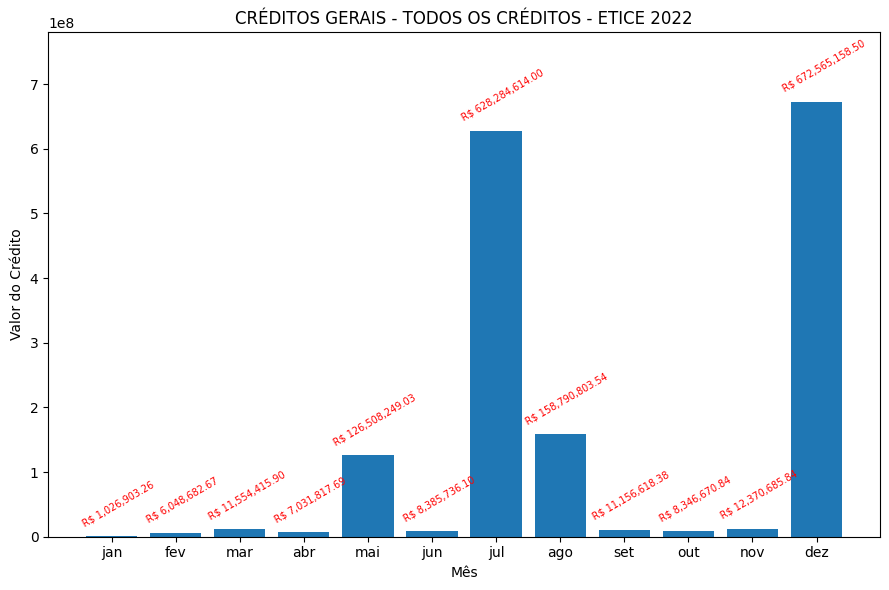

In [62]:
# Faz o Group by 'Mês' e faz o sum 'CRÉDITO'
credit_by_month = df.groupby('Mês')['CRÉDITO'].sum()

# Define a ordem dos meses da coluna Mês
month_order = ['jan', 'fev', 'mar', 'abr', 'mai', 'jun', 'jul', 'ago', 'set', 'out', 'nov', 'dez']
# Reindexa a Série credit_by_month para garantir a ordem dos meses
credit_by_month = credit_by_month.reindex(month_order)

# Cria Gráfico de barras
plt.figure(figsize=(9, 6))
# Define a altura máxima das barras para ajustar o espaço superior
y_max = credit_by_month.max() * 1.16  # Aumenta 15% o valor máximo

bars = plt.bar(credit_by_month.index, credit_by_month.values)
plt.xlabel('Mês')
plt.ylabel('Valor do Crédito')
plt.title('CRÉDITOS GERAIS - TODOS OS CRÉDITOS - ETICE 2022')
plt.ylim(0, y_max)  # Define o limite superior do eixo y

# Adiciona labels no topo das barras na vertical
for bar in bars:
  yval = bar.get_height()
  plt.text(bar.get_x() + bar.get_width()/2, yval, f"     R$ {yval:,.2f}", ha='center', va='bottom', rotation=30,color='Red',fontsize=7)

plt.tight_layout()
plt.show()

In [63]:
# Tabela com os valores por mês usando o formato monetário do real

# Converter a Série credit_by_month para um DataFrame para formatar o valores
credit_df_Geral = pd.DataFrame({'Mês': credit_by_month.index, 'Crédito': credit_by_month.values})

# Formatar a coluna 'CRÉDITO' para o Real R$
credit_df_Geral['Crédito_Real'] = credit_df_Geral['Crédito'].apply(lambda x: "R$ {:,.2f}".format(x))

# A tabela
credit_df_Geral


,Mês,Crédito,Crédito_Real
0,jan,1.026903e+06,"R$ 1,026,903.26"
1,fev,6.048683e+06,"R$ 6,048,682.67"
2,mar,1.155442e+07,"R$ 11,554,415.90"
3,abr,7.031818e+06,"R$ 7,031,817.69"
4,mai,1.265082e+08,"R$ 126,508,249.03"
5,jun,8.385736e+06,"R$ 8,385,736.10"
6,jul,6.282846e+08,"R$ 628,284,614.00"
7,ago,1.587908e+08,"R$ 158,790,803.54"
8,set,1.115662e+07,"R$ 11,156,618.38"
9,out,8.346671e+06,"R$ 8,346,670.84"


# Visão Receitas Brutas que Contem no Histórico a String "NFSTC" - ETICE-**2022**

In [64]:
# Usando o DataFrame df foi gerado um dataframe dfNFSTC que contem a string NFST em "Histórico" e com as linhas das outra colunas de df

# Criar dfNFSTC contendo apenas linhas onde 'HISTÓRICO' contem a string 'NFST'
dfNFSTC = df[df['HISTÓRICO'].str.contains('NFSTC', na=False, case=False)].copy()


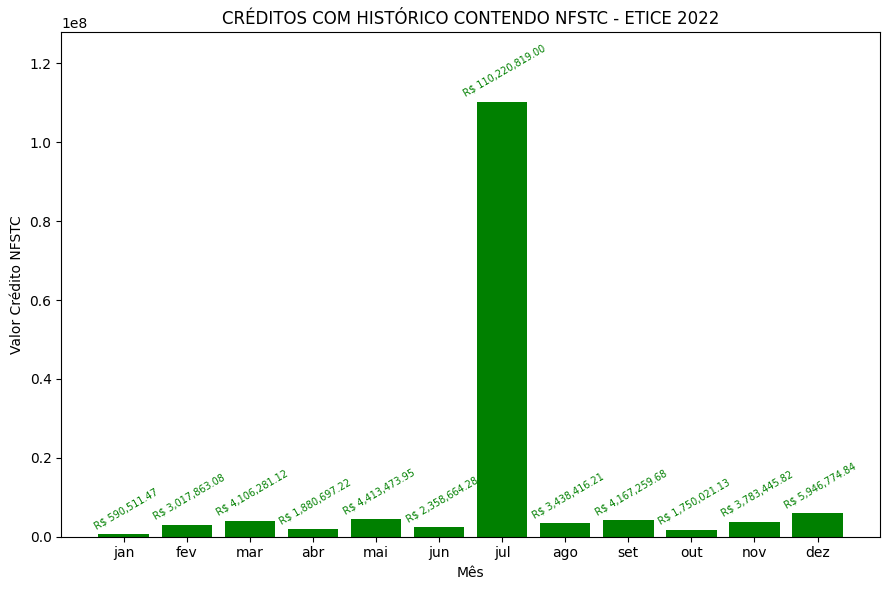

In [65]:

# Faz o Group by 'Mês' e faz o sum 'CRÉDITO' no outro dataframe criado dfNFSTC
credit_by_month = dfNFSTC.groupby('Mês')['CRÉDITO'].sum()

# Define a ordem dos meses da coluna Mês
month_order = ['jan', 'fev', 'mar', 'abr', 'mai', 'jun', 'jul', 'ago', 'set', 'out', 'nov', 'dez']

# Reindexa a Série credit_by_month para garantir a ordem dos meses
credit_by_month = credit_by_month.reindex(month_order)

# Cria Gráfico de barras
plt.figure(figsize=(9, 6))
# Define a altura máxima das barras para ajustar o espaço superior
y_max = credit_by_month.max() * 1.16  # Aumenta 15% o valor máximo

bars = plt.bar(credit_by_month.index, credit_by_month.values, color='Green')
plt.xlabel('Mês')
plt.ylabel('Valor Crédito NFSTC')
plt.title('CRÉDITOS COM HISTÓRICO CONTENDO NFSTC - ETICE 2022')
plt.ylim(0, y_max)  # Define o limite superior do eixo y

# Adiciona labels no topo das barras na vertical
for bar in bars:
  yval = bar.get_height()
  plt.text(bar.get_x() + bar.get_width()/2, yval, f"  R$ {yval:,.2f}", ha='center', va='bottom', rotation=30,color='Green',fontsize=7)

plt.tight_layout()
plt.show()

In [66]:
# Tabela com os valores por mês usando o formato monetário do real

# Converter a Série credit_by_month para um DataFrame para formatar o valores
credit_df_NFSTC = pd.DataFrame({'Mês': credit_by_month.index, 'Crédito': credit_by_month.values})

# Formatar a coluna 'CRÉDITO' para o Real R$
credit_df_NFSTC['Crédito_Real'] = credit_df_NFSTC['Crédito'].apply(lambda x: "R$ {:,.2f}".format(x))

# A tabela
credit_df_NFSTC

,Mês,Crédito,Crédito_Real
0,jan,5.905115e+05,"R$ 590,511.47"
1,fev,3.017863e+06,"R$ 3,017,863.08"
2,mar,4.106281e+06,"R$ 4,106,281.12"
3,abr,1.880697e+06,"R$ 1,880,697.22"
4,mai,4.413474e+06,"R$ 4,413,473.95"
5,jun,2.358664e+06,"R$ 2,358,664.28"
6,jul,1.102208e+08,"R$ 110,220,819.00"
7,ago,3.438416e+06,"R$ 3,438,416.21"
8,set,4.167260e+06,"R$ 4,167,259.68"
9,out,1.750021e+06,"R$ 1,750,021.13"


# Visão Geral Receitas Brutas de HISTÒRICO que contem string "Telecom" - ETICE-**2022**

In [74]:
# Usando o DataFrame df foi gerado um dataframe dfTeleco que contem a string Teleco no campo "Histórico" e com as linhas das outra colunas de df
dfTeleco = df[df['HISTÓRICO'].str.contains('Telecomunica', na=False, case=False)].copy()


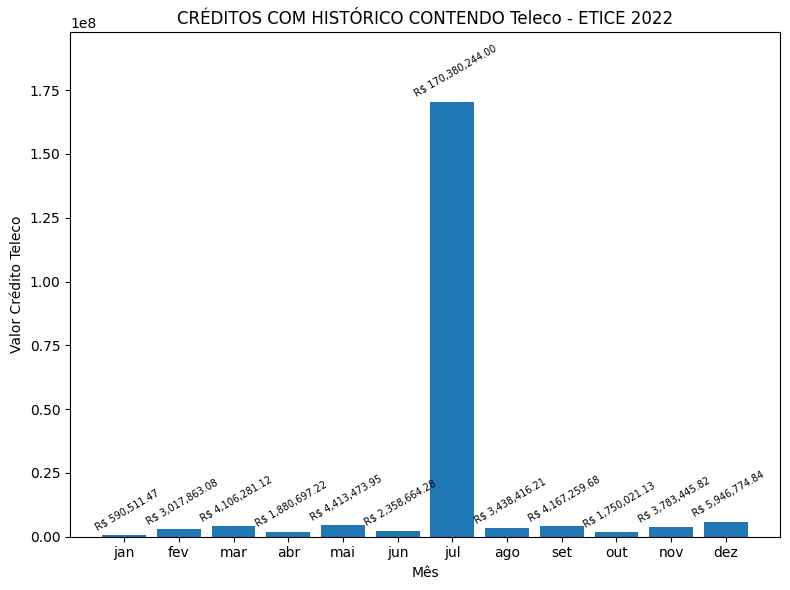

In [70]:
# Faz o Group by 'Mês' e faz o sum 'CRÉDITO' no outro dataframe criado dfNFSTC
credit_by_month = dfTeleco.groupby('Mês')['CRÉDITO'].sum()

# Define a ordem dos meses da coluna Mês
month_order = ['jan', 'fev', 'mar', 'abr', 'mai', 'jun', 'jul', 'ago', 'set', 'out', 'nov', 'dez']

# Reindexa a Série credit_by_month para garantir a ordem dos meses
credit_by_month = credit_by_month.reindex(month_order)

# Cria Gráfico de barras
plt.figure(figsize=(8, 6))
# Define a altura máxima das barras para ajustar o espaço superior
y_max = credit_by_month.max() * 1.16  # Aumenta 15% o valor máximo

bars = plt.bar(credit_by_month.index, credit_by_month.values)
plt.xlabel('Mês')
plt.ylabel('Valor Crédito Teleco')
plt.title('CRÉDITOS COM HISTÓRICO CONTENDO Teleco - ETICE 2022')
plt.ylim(0, y_max)  # Define o limite superior do eixo y

# Adiciona labels no topo das barras na vertical
for bar in bars:
  yval = bar.get_height()
  plt.text(bar.get_x() + bar.get_width()/2, yval, f"  R$ {yval:,.2f}", ha='center', va='bottom', rotation=30,fontsize=7)

plt.tight_layout()
plt.show()

In [40]:
# Tabela com os valores por mês usando o formato monetário do real

# Converter a Série credit_by_month para um DataFrame para formatar o valores
credit_df_Teleco = pd.DataFrame({'Mês': credit_by_month.index, 'Crédito': credit_by_month.values})

# Formatar a coluna 'CRÉDITO' para o Real R$
credit_df_Teleco['Crédito_Real'] = credit_df_Teleco['Crédito'].apply(lambda x: "R$ {:,.2f}".format(x))

# A tabela
credit_df_Teleco

,Mês,Crédito,Crédito_Real
0,jan,5.905115e+05,"R$ 590,511.47"
1,fev,3.017863e+06,"R$ 3,017,863.08"
2,mar,4.106281e+06,"R$ 4,106,281.12"
3,abr,1.880697e+06,"R$ 1,880,697.22"
4,mai,4.413474e+06,"R$ 4,413,473.95"
5,jun,2.358664e+06,"R$ 2,358,664.28"
6,jul,1.703802e+08,"R$ 170,380,244.00"
7,ago,3.438416e+06,"R$ 3,438,416.21"
8,set,4.167260e+06,"R$ 4,167,259.68"
9,out,1.750021e+06,"R$ 1,750,021.13"


NFSTC

In [50]:
# prompt: apresente o df_jul_NFSTC só de julho , com Mês=='jul' e Histórico contem "NFSTC' e aprsente a soma da coluna CRÉDITOS de df_jul_NFSTC

df_jul_NFSTC = df_julho[df_julho['HISTÓRICO'].str.contains('NFSTC', case=False, na=False)].copy()
soma_creditos_jul_NFSTC = df_jul_NFSTC['CRÉDITO'].sum()

print("DataFrame df_jul_NFSTC (julho, com 'NFSTC' no Histórico):")
df_jul_NFSTC


DataFrame df_jul_NFSTC (julho, com 'NFSTC' no Histórico):


,DATA,Mês,HISTÓRICO,CONTRAPARTIDA,CR-Cp,CHAVE,CRÉDITO,Unnamed: 7,CHECK VALUE,SALDO
1069,2022-07-01 00:00:00,jul,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0125 0001,1,1.637501e+09,28239.0,"48.674.610,33C","48.674.610,33",48674610.33
1070,2022-07-01 00:00:00,jul,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0140 0001,1,1.637501e+09,611.0,"48.674.616,44C","48.674.616,44",48674616.44
1071,2022-07-01 00:00:00,jul,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0131 0001,1,1.637501e+09,26641.0,"48.674.882,85C","48.674.882,85",48674882.85
1072,2022-07-01 00:00:00,jul,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0131 0001,1,1.637501e+09,6672.0,"48.674.949,57C","48.674.949,57",48674949.57
1073,2022-07-01 00:00:00,jul,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0131 0001,1,1.637501e+09,5868.0,"48.675.008,25C","48.675.008,25",48675008.25
...,...,...,...,...,...,...,...,...,...,...
1270,2022-07-27 00:00:00,jul,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0153 0001,1,1.637501e+09,51175.0,"56.634.285,92C","56.634.285,92",56634285.92
1271,2022-07-27 00:00:00,jul,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0039 0001,1,1.637501e+09,4729549.0,"56.681.581,41C","56.681.581,41",56681581.41
1272,2022-07-28 00:00:00,jul,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0068 0001,1,1.637501e+09,1704006.0,"56.698.621,47C","56.698.621,47",56698621.47
1273,2022-07-28 00:00:00,jul,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0066 0001,1,1.637501e+09,28736.0,"56.727.357,47C","56.727.357,47",56727357.47


In [51]:
print("\nSoma dos Créditos em df_jul_NFSTC:", soma_creditos_jul_NFSTC)


Soma dos Créditos em df_jul_NFSTC: 110220819.0


TELECO

In [47]:
df_jul_Teleco = df_julho[df_julho['HISTÓRICO'].str.contains('Teleco', case=False, na=False)].copy()

soma_creditos_jul_Teleco = df_jul_Teleco['CRÉDITO'].sum()

print("DataFrame df_jul_Teleco (julho, com 'Teleco' no Histórico):R$ {:.2f}".format(soma_creditos_jul_Teleco))
df_jul_Teleco

DataFrame df_jul_Teleco (julho, com 'Teleco' no Histórico):R$ 110220819.00


,DATA,Mês,HISTÓRICO,CONTRAPARTIDA,CR-Cp,CHAVE,CRÉDITO,Unnamed: 7,CHECK VALUE,SALDO
1069,2022-07-01 00:00:00,jul,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0125 0001,1,1.637501e+09,28239.0,"48.674.610,33C","48.674.610,33",48674610.33
1070,2022-07-01 00:00:00,jul,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0140 0001,1,1.637501e+09,611.0,"48.674.616,44C","48.674.616,44",48674616.44
1071,2022-07-01 00:00:00,jul,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0131 0001,1,1.637501e+09,26641.0,"48.674.882,85C","48.674.882,85",48674882.85
1072,2022-07-01 00:00:00,jul,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0131 0001,1,1.637501e+09,6672.0,"48.674.949,57C","48.674.949,57",48674949.57
1073,2022-07-01 00:00:00,jul,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0131 0001,1,1.637501e+09,5868.0,"48.675.008,25C","48.675.008,25",48675008.25
...,...,...,...,...,...,...,...,...,...,...
1270,2022-07-27 00:00:00,jul,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0153 0001,1,1.637501e+09,51175.0,"56.634.285,92C","56.634.285,92",56634285.92
1271,2022-07-27 00:00:00,jul,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0039 0001,1,1.637501e+09,4729549.0,"56.681.581,41C","56.681.581,41",56681581.41
1272,2022-07-28 00:00:00,jul,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0068 0001,1,1.637501e+09,1704006.0,"56.698.621,47C","56.698.621,47",56698621.47
1273,2022-07-28 00:00:00,jul,Vr. Ref a Prestação de Serviços de Telecomunic...,1.1.02.01.0066 0001,1,1.637501e+09,28736.0,"56.727.357,47C","56.727.357,47",56727357.47


In [48]:
# prompt: print("\nSoma dos Créditos em df_jul_Teleco:", soma_creditos_jul_Teleco) no formato de REal R$

print("\nSoma dos Créditos em df_jul_teleco: R$ {:.2f}".format(soma_creditos_jul_Teleco))


Soma dos Créditos em df_jul_teleco: R$ 110220819.00
